# 12 · Model solution: volume forecasting

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lukasquaderer-lgtm/Linear-regression/blob/master/notebooks/solutions/12_project_volume_forecasting_solution.ipynb)

One reasonable solution. The *Introduction to Statistical Learning* authors report a test R² of about 0.41 for an
AR(5) model on this data and about 0.46 with day-of-week added; we reproduce that and then try tree ensembles.

In [1]:
# Setup: run this cell first (Shift + Enter). Works in Jupyter, VS Code and Google Colab.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from pathlib import Path
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)   # hide library deprecation notices

# Use the local data folder if it exists, otherwise read the CSVs straight from GitHub (e.g. in Colab)
DATA = next((p for p in ["../data/", "../../data/"] if Path(p).exists()), "https://raw.githubusercontent.com/lukasquaderer-lgtm/Linear-regression/master/data/")
pd.set_option("display.precision", 4)
plt.rcParams["figure.figsize"] = (8, 4)

# Answer checker: after an exercise, check("01.1") tells you whether your answer is right
import sys
if Path("../checks.py").exists():
    sys.path.insert(0, "..")  # solution notebooks live one folder down
try:
    from checks import check, check_all
except ImportError:  # in Colab: fetch the checker from GitHub
    import urllib.request
    urllib.request.urlretrieve("https://raw.githubusercontent.com/lukasquaderer-lgtm/Linear-regression/master/notebooks/checks.py", "checks.py")
    from checks import check, check_all
print("Ready. Data folder:", DATA)

Ready. Data folder: ../../data/


In [2]:
# Load a real dataset from the ISLP package (Introduction to Statistical Learning with Python)
import subprocess, sys
def load_islp(name):
    try:
        import ISLP
    except ImportError:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", "--no-deps", "ISLP"], check=True)
        import ISLP
    return pd.read_csv(Path(ISLP.__file__).parent / "data" / f"{name}.csv")

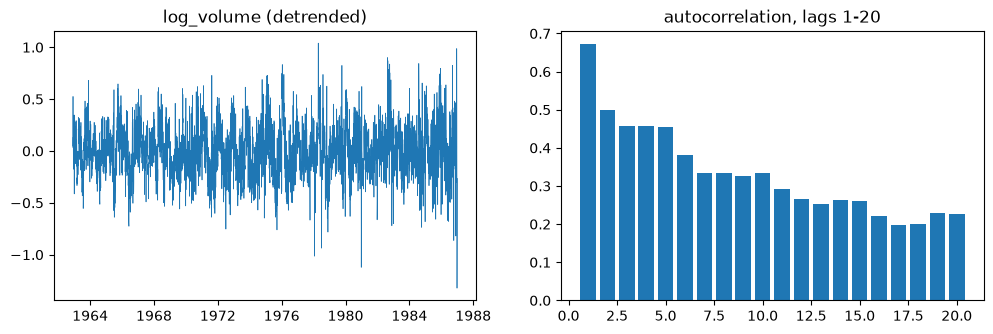

In [3]:
from sklearn.linear_model import LinearRegression, RidgeCV
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import r2_score, mean_squared_error
from statsmodels.tsa.stattools import acf

nyse = load_islp("NYSE"); nyse["date"] = pd.to_datetime(nyse["date"])
fig, ax = plt.subplots(1, 2, figsize=(12, 3.5))
ax[0].plot(nyse["date"], nyse["log_volume"], lw=0.5); ax[0].set_title("log_volume (detrended)")
ax[1].bar(range(1, 21), acf(nyse["log_volume"], nlags=20)[1:]); ax[1].set_title("autocorrelation, lags 1-20"); plt.show()

In [4]:
# 2) lagged features: everything known at the close of t-1
feat = pd.DataFrame(index=nyse.index)
for var in ["log_volume", "DJ_return", "log_volatility"]:
    for L in range(1, 6):
        feat[f"{var}_L{L}"] = nyse[var].shift(L)
dow = pd.get_dummies(nyse["day_of_week"], prefix="dow", drop_first=True, dtype=float)   # known in advance
data = pd.concat([nyse[["date", "log_volume", "train"]], feat, dow], axis=1).dropna()
tr, te = data[data["train"]], data[~data["train"]]
lagvol = [f"log_volume_L{L}" for L in range(1, 6)]
allf = list(feat.columns) + list(dow.columns)
print(f"train {tr['date'].min():%Y-%m-%d} to {tr['date'].max():%Y-%m-%d} ({len(tr)} days) | test {te['date'].min():%Y-%m-%d} to {te['date'].max():%Y-%m-%d} ({len(te)} days)")

train 1962-12-10 to 1979-12-31 (4276 days) | test 1980-01-02 to 1986-12-31 (1770 days)


In [5]:
def report(name, pred):
    return [name, r2_score(te["log_volume"], pred), np.sqrt(mean_squared_error(te["log_volume"], pred))]

rows = [report("Persistence (yesterday)", te["log_volume_L1"])]
ar5 = LinearRegression().fit(tr[lagvol], tr["log_volume"]); rows.append(report("AR(5)", ar5.predict(te[lagvol])))
ar5d = LinearRegression().fit(tr[lagvol + list(dow.columns)], tr["log_volume"]); rows.append(report("AR(5) + day of week", ar5d.predict(te[lagvol + list(dow.columns)])))
lin = RidgeCV(alphas=np.logspace(-3, 3, 13)).fit(tr[allf], tr["log_volume"]); rows.append(report("Ridge, all features", lin.predict(te[allf])))

tscv = TimeSeriesSplit(5)
gb = GridSearchCV(HistGradientBoostingRegressor(random_state=0),
                  {"learning_rate": [0.03, 0.1], "max_depth": [2, 4], "max_iter": [200, 400]}, cv=tscv, scoring="r2").fit(tr[allf], tr["log_volume"])
rows.append(report("Gradient boosting (tuned)", gb.predict(te[allf])))
res = pd.DataFrame(rows, columns=["model", "test R²", "test RMSE"]).set_index("model").round(4)
print("best boosting params:", gb.best_params_); res

best boosting params: {'learning_rate': 0.03, 'max_depth': 2, 'max_iter': 400}


,test R²,test RMSE
model,,
Persistence (yesterday),0.1803,0.2172
AR(5),0.3732,0.1899
AR(5) + day of week,0.4183,0.1829
"Ridge, all features",0.4593,0.1764
Gradient boosting (tuned),0.4463,0.1785


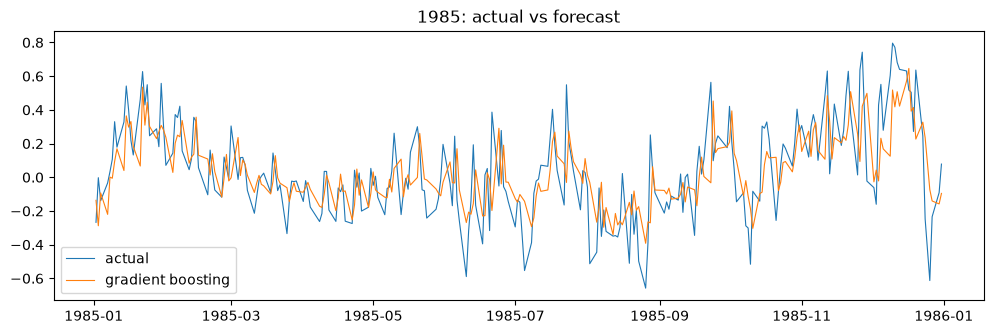

residual autocorrelation lags 1-5: [-0.002 -0.013 -0.003 -0.063 -0.02 ]
day_of_week
fri    -0.027
mon    -0.030
thur    0.019
tues    0.028
wed     0.027
Name: log_volume, dtype: float64


In [6]:
pred = gb.predict(te[allf]); yr = te["date"].dt.year == 1985
plt.figure(figsize=(12, 3.5)); plt.plot(te.loc[yr, "date"], te.loc[yr, "log_volume"], lw=0.8, label="actual")
plt.plot(te.loc[yr, "date"], pred[yr.to_numpy()], lw=0.8, label="gradient boosting"); plt.legend(); plt.title("1985: actual vs forecast"); plt.show()
resid = te["log_volume"] - pred
print("residual autocorrelation lags 1-5:", np.round(acf(resid, nlags=5)[1:], 3))
print(resid.groupby(nyse.loc[te.index, "day_of_week"]).mean().round(3))

### 7) Recommendation (example)
Yesterday's volume alone gives a test R² of about 0.18; an AR(5) raises it to about 0.37, and adding the day of the
week to about 0.42, in line with the textbook result. A ridge regression that also uses lagged returns and volatility is
best at about 0.46. Gradient boosting did not beat it, so the extra complexity is not worth it here. I would deploy the
ridge model: transparent, stable and cheap to re-fit daily, and keep the boosted model as a challenger to re-test each
year.